<a href="https://colab.research.google.com/github/RezzaHarya/Data-Scientist-Exploratory-Data-Analysis/blob/main/Copy_of_Pelatihan_3_Exploratory_Data_Analysis_FIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)
Pada pertemuan kali ini, kita akan berkenalan dengan proses Exploratory Data Analysis (EDA) sebagai langkah awal dalam memahami dataset sebelum masuk ke tahap pemodelan. EDA bertujuan untuk menggali informasi penting dari data melalui teknik statistik sederhana dan visualisasi.

Melalui dataset yang telah disediakan, kita akan mengeksplorasi berbagai aspek data, seperti:

* memahami struktur dan tipe data pada setiap variabel,
* mengidentifikasi nilai yang hilang (missing values) dan data duplikat,
* serta melihat distribusi data dan hubungan antar variabel menggunakan visualisasi.

Pendekatan yang digunakan bersifat eksploratif dan interaktif, di mana peserta akan mencoba berbagai teknik analisis untuk menemukan pola, tren, dan anomali dalam data.

---

Pada pertemuan ini tidak hanya berfokus pada penggunaan tools, tetapi juga pada cara berpikir analitis dalam membaca data dan bagaimana menginterpretasikan grafik, menarik insight awal, serta menentukan langkah preprocessing yang tepat sebelum modeling.

Di akhir sesi, Anda diharapkan mampu:

* memahami karakteristik dataset secara menyeluruh,
* mengidentifikasi permasalahan dalam data yang perlu ditangani,
* serta menghasilkan insight awal yang dapat menjadi dasar dalam proses analisis selanjutnya.

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Persiapan Data

Pada tahap ini, kita akan menggunakan dataset transaksi makanan yang berisi informasi mengenai berbagai pembelian yang dilakukan oleh pelanggan. Dataset ini mencakup data transaksi seperti jenis makanan, jumlah pembelian, harga, serta informasi lain yang relevan untuk dianalisis.

Dataset ini dirancang untuk studi kasus Exploratory Data Analysis (EDA), di mana tujuan utama kita adalah memahami pola pembelian, karakteristik data, serta menemukan insight awal yang dapat digunakan untuk analisis lanjutan.

Data yang digunakan bersifat tabular dan terdiri dari kombinasi fitur numerik maupun kategorikal, sehingga cocok untuk eksplorasi menggunakan teknik statistik dasar dan visualisasi.

Secara umum, dataset ini memuat:

* data transaksi sebagai unit observasi,
* fitur kategorikal seperti jenis produk atau kategori makanan,
* fitur numerik seperti harga, jumlah pembelian, atau total transaksi,
* serta kemungkinan adanya data tidak lengkap (missing values) atau inkonsistensi data.

Cara memuat data set:


```
df=pd.read_csv(".........")
df
```



Dataset akan diakses pada


```
https://drive.google.com/uc?id=1paFsZZPx6fBf3uYrhk3FFZIocUOvCP-h
```



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df=pd.read_csv("/content/dataset_pembelian.csv")
df

,ID Pelanggan,Nama,Jenis_Kelamin,Makanan,Harga_Makanan,Minuman,Harga_Minuman,Total_Bayar,Review
0,1,Vivi,P,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
1,2,Brawid,L,Ayam geprek,16000.0,Es teler,7000.0,23000,5.0
2,3,Zaki,L,Nila bakar,15000.0,Es jeruk,4000.0,19000,3.0
3,4,Ncha,P,Ayam goreng,15000.0,Es buah,8000.0,23000,4.0
4,5,Alwi Fillah,L,Ayam geprek,16000.0,Es jeruk,4000.0,20000,5.0
5,6,Zaki,L,Lele goreng,11000.0,Es teh,3000.0,14000,2.0
6,7,Jati,L,Lele bakar,12000.0,Es teh,3000.0,15000,1.0
7,8,Alwi Fillah,L,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
8,9,Nibras,L,Ayam bakar,16000.0,Es teler,7000.0,23000,3.0
9,10,Agung,L,Nila bakar,15000.0,Es buah,8000.0,23000,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID Pelanggan   34 non-null     int64  
 1   Nama           34 non-null     object 
 2   Jenis_Kelamin  34 non-null     object 
 3   Makanan        34 non-null     object 
 4   Harga_Makanan  33 non-null     float64
 5   Minuman        34 non-null     object 
 6   Harga_Minuman  33 non-null     float64
 7   Total_Bayar    34 non-null     int64  
 8   Review         32 non-null     float64
dtypes: float64(3), int64(2), object(4)
memory usage: 2.5+ KB


# Cleaning Data
**Handle Missing Values**

Selanjutnya, kita akan mengidentifikasi dan menangani nilai yang hilang (missing values) dalam dataset. Keberadaan missing values dapat memengaruhi hasil analisis dan menyebabkan bias jika tidak ditangani dengan tepat.

Langkah awal yang dilakukan adalah mengecek jumlah missing values pada setiap kolom menggunakan kode:


```
df.isnull().sum()
```




In [ ]:
df.isnull().sum()

,0
ID Pelanggan,0
Nama,0
Jenis_Kelamin,0
Makanan,0
Harga_Makanan,1
Minuman,0
Harga_Minuman,1
Total_Bayar,0
Review,2


**Menampilkan Data dengan Missing Values**

Setelah mengetahui jumlah missing values pada setiap kolom, langkah selanjutnya adalah menampilkan baris data yang memiliki nilai kosong. Hal ini bertujuan agar kita dapat melihat secara langsung data mana saja yang perlu diperbaiki.

Kode yang digunakan :

```
null_data = df[df.isnull().any(axis=1)]
null_data
```

.any(axis=1)
artinya kita mengecek setiap baris (row), apakah ada minimal satu nilai yang kosong.



Melalui langkah ini, kita dapat mengidentifikasi baris-baris tertentu yang memiliki nilai kosong, sehingga penanganannya bisa dilakukan secara lebih spesifik dan terarah.



In [ ]:
null_data = df[df.isnull().any(axis=1)]
null_data

,ID Pelanggan,Nama,Jenis_Kelamin,Makanan,Harga_Makanan,Minuman,Harga_Minuman,Total_Bayar,Review
10,11,Arifin,L,Nila goreng,NaN,Es teh,3000.0,17000,3.0
15,16,Adit,L,Nila goreng,14000.0,Es teh,NaN,17000,4.0
20,20,Lukman,L,Ayam geprek,16000.0,Jus,5000.0,21000,NaN
23,23,Daus,L,Nila bakar,15000.0,Es buah,8000.0,23000,NaN


**Penanganan Missing Values pada Kolom Review**

Berdasarkan hasil pengecekan sebelumnya, nilai yang hilang (missing values) pada dataset ditangani dengan dua pendekatan, yaitu pengisian secara manual dan imputasi statistik.

Untuk beberapa data yang diketahui konteksnya, nilai kosong dapat diisi secara langsung agar tetap sesuai dengan kondisi sebenarnya.

Untuk kolom Review yang bersifat numerik misalnya rating, nilai kosong diisi menggunakan nilai tengah (median). Median dipilih karena lebih stabil dan tidak mudah terpengaruh oleh nilai ekstrem (outlier).

Mengisi nilai kosong pada kolom Review dengan nilai median:  


```
df['Review'].fillna(df['Review'].median(), inplace=True)
df
```

Mengubah nilai pada data tertentu


```
df.loc[10, 'Harga_Makanan'] = 14000
df.loc[15, 'Harga_Minuman'] = 3000
```




In [ ]:
#Penanganan Missing Values pada Kolom Review

df['Review'].fillna(df['Review'].median(), inplace=True)
df

/tmp/ipykernel_7907/4278677653.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Review'].fillna(df['Review'].median(), inplace=True)


,ID Pelanggan,Nama,Jenis_Kelamin,Makanan,Harga_Makanan,Minuman,Harga_Minuman,Total_Bayar,Review
0,1,Vivi,P,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
1,2,Brawid,L,Ayam geprek,16000.0,Es teler,7000.0,23000,5.0
2,3,Zaki,L,Nila bakar,15000.0,Es jeruk,4000.0,19000,3.0
3,4,Ncha,P,Ayam goreng,15000.0,Es buah,8000.0,23000,4.0
4,5,Alwi Fillah,L,Ayam geprek,16000.0,Es jeruk,4000.0,20000,5.0
5,6,Zaki,L,Lele goreng,11000.0,Es teh,3000.0,14000,2.0
6,7,Jati,L,Lele bakar,12000.0,Es teh,3000.0,15000,1.0
7,8,Alwi Fillah,L,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
8,9,Nibras,L,Ayam bakar,16000.0,Es teler,7000.0,23000,3.0
9,10,Agung,L,Nila bakar,15000.0,Es buah,8000.0,23000,5.0


In [ ]:
#Mengecek kembali jumlah missing values pada setiap kolom
df.isnull().sum()

,0
ID Pelanggan,0
Nama,0
Jenis_Kelamin,0
Makanan,0
Harga_Makanan,1
Minuman,0
Harga_Minuman,1
Total_Bayar,0
Review,0


In [ ]:
df.loc[10, 'Harga_Makanan'] = 10000
df.loc[15, 'Harga_Minuman'] = 3000
df

,ID Pelanggan,Nama,Jenis_Kelamin,Makanan,Harga_Makanan,Minuman,Harga_Minuman,Total_Bayar,Review
0,1,Vivi,P,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
1,2,Brawid,L,Ayam geprek,16000.0,Es teler,7000.0,23000,5.0
2,3,Zaki,L,Nila bakar,15000.0,Es jeruk,4000.0,19000,3.0
3,4,Ncha,P,Ayam goreng,15000.0,Es buah,8000.0,23000,4.0
4,5,Alwi Fillah,L,Ayam geprek,16000.0,Es jeruk,4000.0,20000,5.0
5,6,Zaki,L,Lele goreng,11000.0,Es teh,3000.0,14000,2.0
6,7,Jati,L,Lele bakar,12000.0,Es teh,3000.0,15000,1.0
7,8,Alwi Fillah,L,Ayam bakar,16000.0,Jus,5000.0,21000,4.0
8,9,Nibras,L,Ayam bakar,16000.0,Es teler,7000.0,23000,3.0
9,10,Agung,L,Nila bakar,15000.0,Es buah,8000.0,23000,5.0


In [ ]:
df.isnull().sum()

,0
ID Pelanggan,0
Nama,0
Jenis_Kelamin,0
Makanan,0
Harga_Makanan,0
Minuman,0
Harga_Minuman,0
Total_Bayar,0
Review,0


**Handle Duplicate Data**

 Pada tahap ini, kita akan mengecek apakah terdapat data yang duplikat dalam dataset.
  Data duplikat adalah baris data yang muncul lebih dari satu kali dan dapat menyebabkan hasil analisis menjadi tidak akurat.
 * Mengecek duplikat seluruh baris bisa menggunakan sintaks


```
df.duplicated().sum()
```
 * Mengecek duplikat berdasarkan kolom tertentu


```
df_duplicated = df[df.duplicated(subset='ID Pelanggan')]
df_duplicated
```
* Menghapus baris yang duplikat secara keseluruhan

```
df.drop_duplicates(inplace=True)
```
* Menghapus baris yang duplikat secara keseluruhan

```
df.drop_duplicates(subset='ID Pelanggan',inplace=True)
```





In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df_duplicated = df[df.duplicated(subset='ID Pelanggan')]
df_duplicated

,ID Pelanggan,Nama,Jenis_Kelamin,Makanan,Harga_Makanan,Minuman,Harga_Minuman,Total_Bayar,Review
17,3,Daus,L,Nila bakar,15000.0,Es jeruk,4000.0,19000,3.0
33,9,Echa,P,Ayam bakar,16000.0,Es teler,7000.0,23000,3.0


In [ ]:
#Menghapus baris yang duplikat secara keseluruhan
df.drop_duplicates(inplace=True)


# Analisis statistik dasar

Pada tahap ini, kita melakukan analisis statistik dasar dengan melakukan

**Visualisasi Distribusi Data**

Selanjutnya, kita akan melihat distribusi dari Total_Bayar menggunakan histogram.


```
df_hist = df['Total_Bayar']
plt.hist(df_hist)
plt.show()
```
Histogram digunakan untuk:

mengetahui sebaran nilai pada data,
melihat apakah data cenderung normal atau tidak,

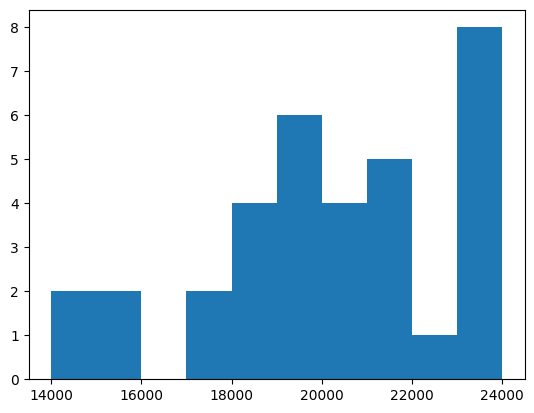

In [ ]:
df_hist = df['Total_Bayar']
plt.hist(df_hist)
plt.show()

**Visualisasi Hubungan Antar Variabel**

Untuk melihat hubungan antara total pembayaran dan harga makanan, digunakan scatter plot berikut:



```
sns.scatterplot(x=df['Harga_Makanan'], y=df['Total_Bayar'])
plt.xlabel("Harga Makanan")
plt.ylabel("Total Bayar")
plt.title("Hubungan Harga Makanan dan Total Bayar")
plt.show()
```


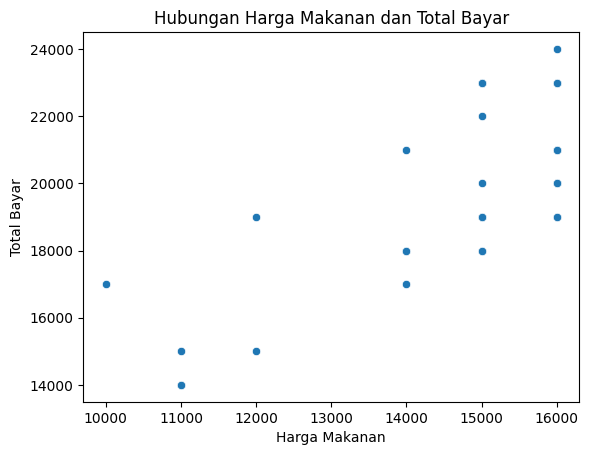

In [ ]:
sns.scatterplot(x=df['Harga_Makanan'], y=df['Total_Bayar'])
plt.xlabel("Harga Makanan")
plt.ylabel("Total Bayar")
plt.title("Hubungan Harga Makanan dan Total Bayar")
plt.show()

**Transformasi Data Kategorikal**

Mengubah data kategorikal menjadi bentuk numerik. Proses ini disebut encoding, dan biasanya diperlukan jika data akan digunakan untuk analisis lanjutan atau pemodelan.

Tujuan Encoding

* Memudahkan data untuk diproses oleh komputer
* Digunakan untuk tahap lanjutan seperti analisis statistik atau machine learning
* Mengubah data teks menjadi format numerik


In [ ]:
df['Makanan'].value_counts()

,count
Makanan,
Ayam geprek,7
Nila bakar,7
Ayam bakar,6
Nila goreng,5
Ayam goreng,4
Lele goreng,3
Lele bakar,2


In [ ]:
makanan_rep = {'Ayam geprek':0, 'Nila bakar':1, 'Ayam bakar':2, 'Nila goreng':3, 'Ayam goreng':4, 'Lele goreng':5,  'Lele bakar':6}
df = df.replace({'Makanan':makanan_rep})
df.head(6)

,ID Pelanggan,Nama,Jenis_Kelamin,Makanan,Harga_Makanan,Minuman,Harga_Minuman,Total_Bayar,Review
0,1,Vivi,P,2,16000.0,Jus,5000.0,21000,4.0
1,2,Brawid,L,0,16000.0,Es teler,7000.0,23000,5.0
2,3,Zaki,L,1,15000.0,Es jeruk,4000.0,19000,3.0
3,4,Ncha,P,4,15000.0,Es buah,8000.0,23000,4.0
4,5,Alwi Fillah,L,0,16000.0,Es jeruk,4000.0,20000,5.0
5,6,Zaki,L,5,11000.0,Es teh,3000.0,14000,2.0


In [ ]:
df["Minuman"].value_counts()

,count
Minuman,
1,9
0,9
3,6
2,5
4,5


In [ ]:
minuman_rep ={'Es teh':0, 'Es jeruk':1, 'Jus':2, 'Es teler':3, 'Es buah':4}
df = df.replace({'Minuman':minuman_rep})
df.tail(6)

/tmp/ipykernel_7907/4270775781.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Minuman':minuman_rep})


,ID Pelanggan,Nama,Jenis_Kelamin,Makanan,Harga_Makanan,Minuman,Harga_Minuman,Total_Bayar,Review
28,28,Agung,L,3,14000.0,1,4000.0,18000,4.0
29,29,Bayu,L,5,11000.0,0,3000.0,14000,2.0
30,30,Alwi Marom,L,1,15000.0,0,3000.0,18000,3.0
31,31,Ima,P,0,16000.0,1,4000.0,20000,4.0
32,32,Alwi Marom,L,2,16000.0,4,8000.0,24000,3.0
33,9,Echa,P,2,16000.0,3,7000.0,23000,3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID Pelanggan   34 non-null     int64  
 1   Nama           34 non-null     object 
 2   Jenis_Kelamin  34 non-null     object 
 3   Makanan        34 non-null     int64  
 4   Harga_Makanan  34 non-null     float64
 5   Minuman        34 non-null     int64  
 6   Harga_Minuman  34 non-null     float64
 7   Total_Bayar    34 non-null     int64  
 8   Review         34 non-null     float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.5+ KB


**Analisis Hubungan Antar Variabel (Correlation)**

Pada tahap ini, kita ingin mengetahui hubungan antar variabel numerik dalam dataset. Untuk itu, digunakan metode korelasi yang menunjukkan seberapa kuat hubungan antar variabel.

*“Kalau nilainya tinggi, berarti dua variabel itu saling berhubungan.”*

Sebelum menghitung korelasi, kita menghapus kolom yang tidak relevan atau bersifat kategorikal seperti Nama dan Jenis_Kelamin, karena tidak dapat dihitung korelasinya secara langsung.



```
data_relationship = df.drop(['Nama', 'Jenis_Kelamin'], axis='columns')
data_relationship.corr()
```



In [ ]:
data_relationship = df.drop(['Nama', 'Jenis_Kelamin'], axis='columns')
data_relationship.corr()

,ID Pelanggan,Makanan,Harga_Makanan,Minuman,Harga_Minuman,Total_Bayar,Review
ID Pelanggan,1.000000,0.074660,-0.075790,-0.135096,-0.129252,-0.159416,-0.125416
Makanan,0.074660,1.000000,-0.738988,-0.161656,-0.141210,-0.553665,-0.260442
Harga_Makanan,-0.075790,-0.738988,1.000000,0.354916,0.314939,0.741734,0.315656
Minuman,-0.135096,-0.161656,0.354916,1.000000,0.992212,0.850354,0.210125
Harga_Minuman,-0.129252,-0.141210,0.314939,0.992212,1.000000,0.834210,0.183677
Total_Bayar,-0.159416,-0.553665,0.741734,0.850354,0.834210,1.000000,0.314369
Review,-0.125416,-0.260442,0.315656,0.210125,0.183677,0.314369,1.000000


**Visualisasi Korelasi dengan Heatmap**

Setelah menghitung nilai korelasi antar variabel, kita dapat memvisualisasikannya menggunakan heatmap agar lebih mudah dibaca dan dipahami.


```
corelasi_matrix = df[['ID Pelanggan', 'Makanan', 'Harga_Makanan', 'Minuman', 'Harga_Minuman', 'Total_Bayar', 'Review']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corelasi_matrix, annot=True, cmap='coolwarm')
plt.title('Korelasi Matrix pada Pesanan Pelanggan')
plt.show()
```


*“Semakin merah warnanya, semakin berkorelasi secara positif.”*


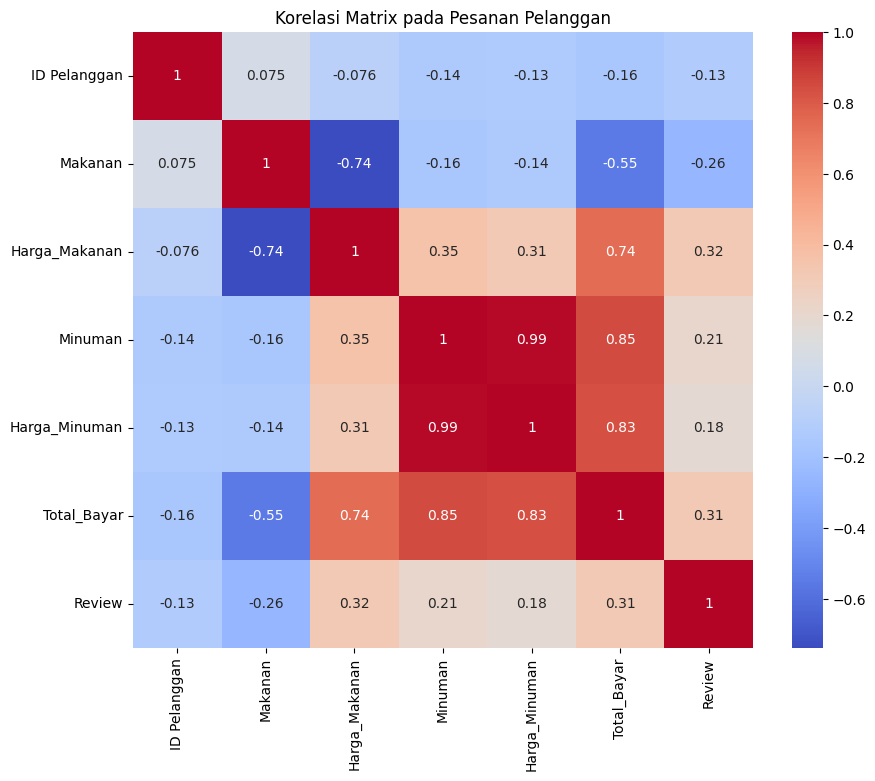

In [ ]:
corelasi_matrix = df[['ID Pelanggan', 'Makanan', 'Harga_Makanan', 'Minuman', 'Harga_Minuman', 'Total_Bayar', 'Review']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corelasi_matrix, annot=True, cmap='coolwarm')
plt.title('Korelasi Matrix pada Pesanan Pelanggan')
plt.show()

# Kuis Praktikum

📝 Petunjuk Umum:
Load dataset melalui link Google Drive yang telah disediakan.

1.   Kerjakan setiap soal secara berurutan.
2. Setiap soal mewakili materi yang sudah dipelajari pada praktikum.
3. Gunakan kode Python (pandas, matplotlib, seaborn) untuk menjawab.
5. Waktu pengerjaan: 30 menit.



#Soal 1 : Import Library

Silahkan Import library yang dibutuhkan untuk analisis data:

* pandas
* numpy
* matplotlib
* seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Soal 2 – Load Dataset

Silahkan Load dataset menggunakan link Google Drive [Data Set Challange](https://drive.google.com/uc?id=1h7w3O912x4Iuez0_9QvgDnOJnSSHYrMI)

Tampilkan 5 data teratas

In [ ]:
df=pd.read_csv("/content/dataset_mahasiswa_challenge.csv")
df

,ID Mahasiswa,Nama,Jenis_Kelamin,Universitas,IPK,Kehadiran,Nilai_Tugas,Nilai_UTS,Nilai_UAS,Total_Nilai
0,1,Alya,L,Universitas Amikom,3.17,69,84.0,78,73,77.8
1,2,Bima,L,Universitas Amikom,2.92,66,65.0,63,72,67.2
2,3,Citra,P,Universitas Amikom,3.59,66,88.0,64,82,78.4
3,4,Dimas,L,Universitas Amikom,3.57,72,84.0,100,98,94.4
4,5,Eka,P,Universitas Amikom,3.60,80,93.0,64,67,73.9
...,...,...,...,...,...,...,...,...,...,...
62,46,Uli,L,Universitas Amikom,3.96,64,NaN,92,68,82.1
63,11,Karin,L,Universitas Amikom,3.21,64,96.0,80,61,76.9
64,39,Nanda,P,Universitas Amikom,3.05,72,81.0,81,70,76.3
65,35,Joko,P,Universitas Amikom,NaN,93,77.0,90,86,84.2


# Soal 3 – Data Cleaning (Missing Values)

1. Tampilkan informasi dataset
2. Cek jumlah missing values di setiap kolom
3. Isi missing value pada:
     * Kolom IPK menggunakan mean
     * Kolom Nilai_Tugas menggunakan median
4. Tampilkan kembali dataset setelah cleaning



In [ ]:
df.isnull().sum()

,0
ID Mahasiswa,0
Nama,0
Jenis_Kelamin,0
Universitas,0
IPK,5
Kehadiran,0
Nilai_Tugas,6
Nilai_UTS,0
Nilai_UAS,0
Total_Nilai,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66 entries, 0 to 66
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID Mahasiswa   66 non-null     int64  
 1   Nama           66 non-null     object 
 2   Jenis_Kelamin  66 non-null     int64  
 3   Universitas    66 non-null     object 
 4   IPK            66 non-null     float64
 5   Kehadiran      66 non-null     int64  
 6   Nilai_Tugas    66 non-null     float64
 7   Nilai_UTS      66 non-null     int64  
 8   Nilai_UAS      66 non-null     int64  
 9   Total_Nilai    66 non-null     float64
dtypes: float64(3), int64(5), object(2)
memory usage: 5.7+ KB


In [ ]:
null_data = df[df.isnull().any(axis=1)]
null_data

,ID Mahasiswa,Nama,Jenis_Kelamin,Universitas,IPK,Kehadiran,Nilai_Tugas,Nilai_UTS,Nilai_UAS,Total_Nilai
6,7,Gita,P,Universitas Amikom,NaN,99,NaN,89,77,84.5
11,12,Luthfi,L,Universitas Amikom,NaN,61,87.0,97,73,84.4
26,27,Bella,P,Universitas Amikom,3.40,93,NaN,71,93,83.4
32,33,Hilda,P,Universitas Amikom,4.00,94,NaN,70,62,68.3
34,35,Joko,P,Universitas Amikom,NaN,93,76.0,90,86,84.2
44,45,Tari,P,Universitas Amikom,2.62,63,NaN,99,66,81.0
45,46,Uli,L,Universitas Amikom,3.96,64,NaN,92,68,82.1
50,51,Andi,L,Universitas Amikom,NaN,98,89.0,90,67,80.5
62,46,Uli,L,Universitas Amikom,3.96,64,NaN,92,68,82.1
65,35,Joko,P,Universitas Amikom,NaN,93,77.0,90,86,84.2


In [ ]:
df['IPK'].fillna(df['IPK'].mean(), inplace=True)
df

/tmp/ipykernel_7907/2847416700.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['IPK'].fillna(df['IPK'].mean(), inplace=True)


,ID Mahasiswa,Nama,Jenis_Kelamin,Universitas,IPK,Kehadiran,Nilai_Tugas,Nilai_UTS,Nilai_UAS,Total_Nilai
0,1,Alya,L,Universitas Amikom,3.170000,69,84.0,78,73,77.8
1,2,Bima,L,Universitas Amikom,2.920000,66,65.0,63,72,67.2
2,3,Citra,P,Universitas Amikom,3.590000,66,88.0,64,82,78.4
3,4,Dimas,L,Universitas Amikom,3.570000,72,84.0,100,98,94.4
4,5,Eka,P,Universitas Amikom,3.600000,80,93.0,64,67,73.9
...,...,...,...,...,...,...,...,...,...,...
62,46,Uli,L,Universitas Amikom,3.960000,64,NaN,92,68,82.1
63,11,Karin,L,Universitas Amikom,3.210000,64,96.0,80,61,76.9
64,39,Nanda,P,Universitas Amikom,3.050000,72,81.0,81,70,76.3
65,35,Joko,P,Universitas Amikom,3.343871,93,77.0,90,86,84.2


In [ ]:
df['Nilai_Tugas'].fillna(df['Nilai_Tugas'].median(), inplace=True)
df

/tmp/ipykernel_7907/1345035421.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Nilai_Tugas'].fillna(df['Nilai_Tugas'].median(), inplace=True)


,ID Mahasiswa,Nama,Jenis_Kelamin,Universitas,IPK,Kehadiran,Nilai_Tugas,Nilai_UTS,Nilai_UAS,Total_Nilai
0,1,Alya,L,Universitas Amikom,3.170000,69,84.0,78,73,77.8
1,2,Bima,L,Universitas Amikom,2.920000,66,65.0,63,72,67.2
2,3,Citra,P,Universitas Amikom,3.590000,66,88.0,64,82,78.4
3,4,Dimas,L,Universitas Amikom,3.570000,72,84.0,100,98,94.4
4,5,Eka,P,Universitas Amikom,3.600000,80,93.0,64,67,73.9
...,...,...,...,...,...,...,...,...,...,...
62,46,Uli,L,Universitas Amikom,3.960000,64,82.0,92,68,82.1
63,11,Karin,L,Universitas Amikom,3.210000,64,96.0,80,61,76.9
64,39,Nanda,P,Universitas Amikom,3.050000,72,81.0,81,70,76.3
65,35,Joko,P,Universitas Amikom,3.343871,93,77.0,90,86,84.2


In [ ]:
df.isnull().sum()

,0
ID Mahasiswa,0
Nama,0
Jenis_Kelamin,0
Universitas,0
IPK,0
Kehadiran,0
Nilai_Tugas,0
Nilai_UTS,0
Nilai_UAS,0
Total_Nilai,0


# Soal 4 – Duplicate Data
1. Silahkan cek apakah terdapat data dengan ID Mahasiswa yang sama
2. Jika ada, maka tampilkan data yang memiliki ID duplikat
3. Hapus data duplikat berdasarkan ID Mahasiswa





In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df_duplicated = df[df.duplicated(subset='ID Mahasiswa')]
df_duplicated

,ID Mahasiswa,Nama,Jenis_Kelamin,Universitas,IPK,Kehadiran,Nilai_Tugas,Nilai_UTS,Nilai_UAS,Total_Nilai
62,46,Uli,L,Universitas Amikom,3.960000,64,82.0,92,68,82.1
63,11,Karin,L,Universitas Amikom,3.210000,64,96.0,80,61,76.9
64,39,Nanda,P,Universitas Amikom,3.050000,72,81.0,81,70,76.3
65,35,Joko,P,Universitas Amikom,3.343871,93,77.0,90,86,84.2
66,26,Adit,L,Universitas Amikom,3.950000,86,65.0,84,75,74.4


In [ ]:
#Menghapus baris yang duplikat secara keseluruhan
df.drop_duplicates(inplace=True)

# Soal 5 - Histogram
* Buat histogram dari Total_Nilai
* Berikan judul grafik

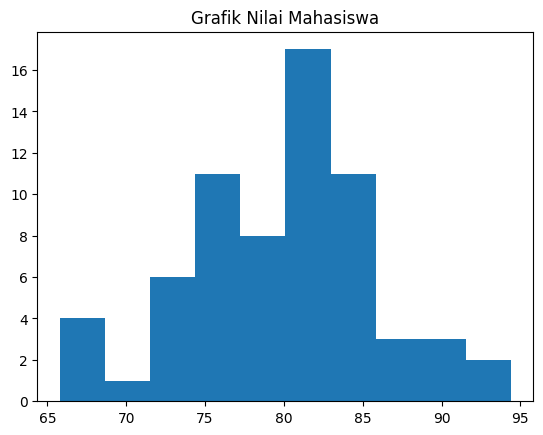

In [ ]:
df_hist = df['Total_Nilai']
plt.hist(df_hist)
plt.title("Grafik Nilai Mahasiswa")
plt.show()

# Soal 6 – Encoding Data
Ubah kolom Jenis_Kelamin
1. L = 0
2. P = 1

In [ ]:
Jenis_Kelamin_rep = {'L':0, 'P':1}
df = df.replace({'Jenis_Kelamin':Jenis_Kelamin_rep})
df

,ID Mahasiswa,Nama,Jenis_Kelamin,Universitas,IPK,Kehadiran,Nilai_Tugas,Nilai_UTS,Nilai_UAS,Total_Nilai
0,1,Alya,0,Universitas Amikom,3.170000,69,84.0,78,73,77.8
1,2,Bima,0,Universitas Amikom,2.920000,66,65.0,63,72,67.2
2,3,Citra,1,Universitas Amikom,3.590000,66,88.0,64,82,78.4
3,4,Dimas,0,Universitas Amikom,3.570000,72,84.0,100,98,94.4
4,5,Eka,1,Universitas Amikom,3.600000,80,93.0,64,67,73.9
...,...,...,...,...,...,...,...,...,...,...
61,62,Laras,0,Universitas Amikom,2.660000,61,85.0,88,66,78.3
63,11,Karin,0,Universitas Amikom,3.210000,64,96.0,80,61,76.9
64,39,Nanda,1,Universitas Amikom,3.050000,72,81.0,81,70,76.3
65,35,Joko,1,Universitas Amikom,3.343871,93,77.0,90,86,84.2


# Soal 7 - Korelasi
Tampilkan dalam bentuk heatmap, jelaskan sepemahamanmu

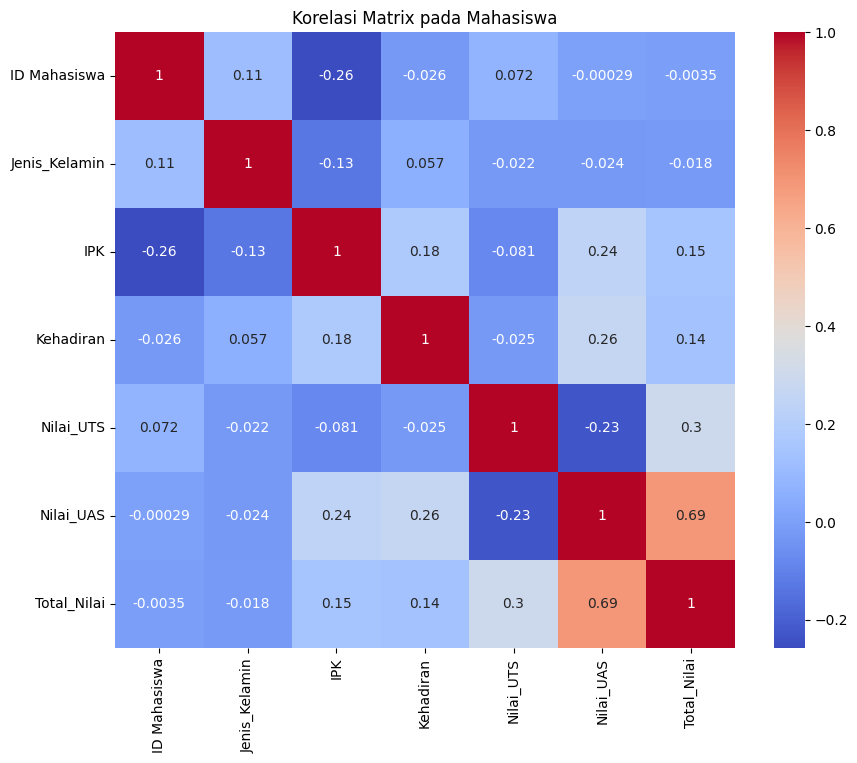

In [ ]:
corelasi_matrix = df[['ID Mahasiswa',  'Jenis_Kelamin', 'IPK', 'Kehadiran', 'Nilai_UTS', 'Nilai_UAS', 'Total_Nilai']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corelasi_matrix, annot=True, cmap='coolwarm')
plt.title('Korelasi Matrix pada Mahasiswa')
plt.show()

**Selamat Mengerjakan All**